In [68]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

### Carga de las capas

In [69]:
#se utiliza el relative path de la capa shp
fallas = gpd.read_file('Datos/Mapa_GeolB3gico_de_Colombia_2015._Escala_1%3A1.000.000.geojson') 
depart = gpd.read_file('Datos/Servicio-23\Departamentos_Abril_2026_shp\Depto.shp')

### Revisar sistemas de coordenadas

In [70]:
depart.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [71]:
fallas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [72]:
#se hace la conversion de coordenadas de la capa de fallas de 4326 a 9377
fallas_rpj = fallas.to_crs('epsg:9377')

### Columna de distancia

In [73]:
# se crea una nueva columna en metros
fallas_rpj['length_m'] = fallas_rpj.geometry.length
# ver los primeros 10 resultados
print(fallas_rpj[['NombreFalla', 'length_m']].head(10))

# Check statistics
print("\nEstadisticas de distancia (m):")
print(f"Promedio: {fallas_rpj['length_m'].mean():.2f} m")
print(f"Mediana: {fallas_rpj['length_m'].median():.2f} m")
print(f"Min: {fallas_rpj['length_m'].min():.2f} m")
print(f"Max: {fallas_rpj['length_m'].max():.2f} m")

         NombreFalla      length_m
0                NaN  15404.917350
1  Falla de Chaguaca   1546.193935
2  Falla de Chaguaca  17444.410994
3   Falla de Soápaga   9303.214150
4   Falla de Soápaga   3463.406492
5   Falla de Soápaga   2807.692973
6                NaN    974.720636
7                NaN   1749.728162
8                NaN    867.532904
9                NaN   2247.716478

Estadisticas de distancia (m):
Promedio: 11783.05 m
Mediana: 6285.24 m
Min: 0.00 m
Max: 414653.86 m


### Columna pesos

In [74]:
# Muestra un arreglo con todos los tipos diferentes en la columna 'tipo'
tipos_unicos = fallas_rpj['Tipo'].unique()
print(tipos_unicos)

<StringArray>
[                                    'Falla',
          'Falla inversa o de cabalgamiento',
                            'Falla cubierta',
 'Falla inversa o de cabalgamiento cubierta',
                    'Falla de rumbo dextral',
                  'Falla de rumbo sinestral',
                               'Lineamiento',
           'Falla de rumbo dextral cubierta',
         'Falla de rumbo sinestral cubierta',
                            'Falla inferida',
                     'Falla normal cubierta',
                              'Falla normal',
           'Falla de rumbo dextral inferida',
         'Falla de rumbo sinestral inferida',
                     'Falla normal inferida',
 'Falla inversa o de cabalgamiento inferida']
Length: 16, dtype: str


In [75]:
# 1. Definimos las listas de tipos para cada categoría
grupo_3 = [
    'Falla', 'Falla cubierta', 'Lineamiento', 'Falla inferida',
    'Falla inversa o de cabalgamiento', 'Falla inversa o de cabalgamiento cubierta', 
    'Falla inversa o de cabalgamiento inferida'
]

grupo_5 = [
    'Falla de rumbo dextral', 'Falla de rumbo sinestral', 
    'Falla de rumbo dextral cubierta', 'Falla de rumbo sinestral cubierta', 
    'Falla de rumbo dextral inferida', 'Falla de rumbo sinestral inferida'
]

grupo_4 = [
    'Falla normal cubierta', 'Falla normal', 'Falla normal inferida'
]

# 2. Definimos las condiciones lógicas
condiciones = [
    fallas_rpj['Tipo'].isin(grupo_3),
    fallas_rpj['Tipo'].isin(grupo_5),
    fallas_rpj['Tipo'].isin(grupo_4)
]

# 3. Definimos los valores que corresponden a cada condición
valores = [3, 5, 4]

# 4. Creamos la nueva columna
# El 'default=0' es para cualquier caso que no esté en las listas anteriores
fallas_rpj['calificacion'] = np.select(condiciones, valores, default=0)

# Verificamos los resultados
print(fallas_rpj[['Tipo', 'calificacion']].head(10))

                               Tipo  calificacion
0                             Falla             3
1                             Falla             3
2                             Falla             3
3  Falla inversa o de cabalgamiento             3
4                    Falla cubierta             3
5                             Falla             3
6                    Falla cubierta             3
7                             Falla             3
8                    Falla cubierta             3
9                             Falla             3


In [76]:
# Revisa si hay algún valor igual a 0 y devuelve True o False
hay_ceros = (fallas_rpj['calificacion'] == 0).any()
print(f"¿Hay registros con valor 0?: {hay_ceros}")

¿Hay registros con valor 0?: False


### Columna zona de daño

In [77]:
# se crea una nueva columna para la zona de daño
fallas_rpj['zona_dano'] = (fallas_rpj['length_m'] * 0.3) / 100
print(fallas_rpj[['NombreFalla', 'zona_dano']].head(10))

         NombreFalla  zona_dano
0                NaN  46.214752
1  Falla de Chaguaca   4.638582
2  Falla de Chaguaca  52.333233
3   Falla de Soápaga  27.909642
4   Falla de Soápaga  10.390219
5   Falla de Soápaga   8.423079
6                NaN   2.924162
7                NaN   5.249184
8                NaN   2.602599
9                NaN   6.743149


### Buffer

In [78]:
# Creamos una copia para mantener la capa de líneas original intacta
fallas_buffer = fallas_rpj.copy()

# Se aplica el buffer usando la columna 'zona_dano'
fallas_buffer['geometry'] = fallas_rpj.geometry.buffer(fallas_rpj['zona_dano'])

### Mapa zonas de daño

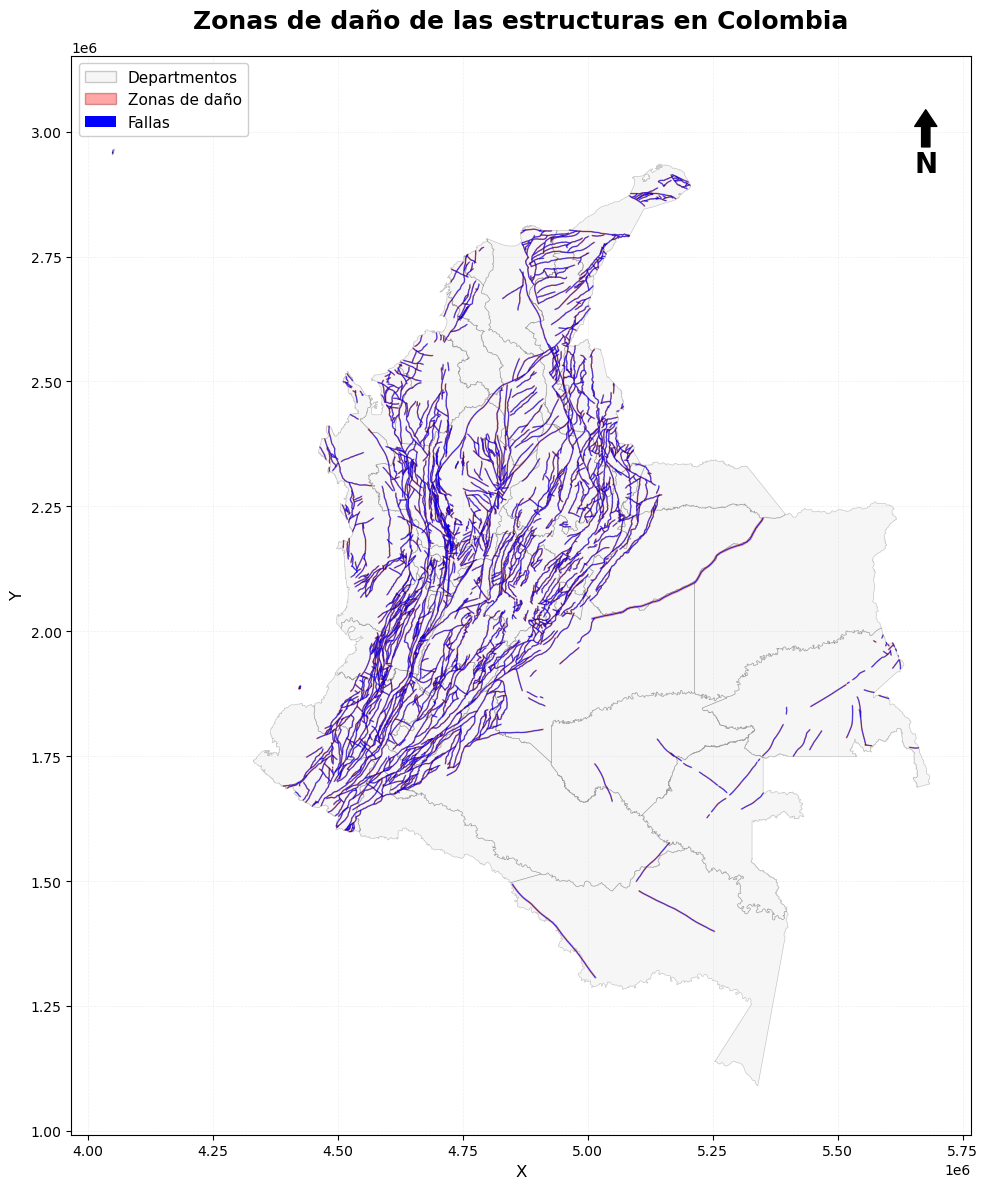

In [79]:
fig, ax = plt.subplots(figsize=(16, 12))

# Departamentos
depart.plot(ax=ax, alpha=0.2, edgecolor='black', color='lightgray', linewidth=0.5)

# Fallas
fallas_rpj.plot(ax=ax, alpha=0.9, color='blue', linewidth=0.5)

# Buffer
fallas_buffer.plot(ax=ax, alpha=0.35, color='red', edgecolor='darkred', linewidth=1)

# Layout
plt.title('Zonas de daño de las estructuras en Colombia', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Leyenda
legend_elements = [
    Patch(facecolor='lightgray', edgecolor='black', alpha=0.2, label='Departmentos'),
    Patch(facecolor='red', edgecolor='darkred', alpha=0.35, label='Zonas de daño'),
    Patch(facecolor='blue', label='Fallas')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

x, y, arrow_length = 0.95, 0.95, 0.05 

ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', edgecolor='black', width=6, headwidth=16, headlength=12),
            ha='center', va='center', fontsize=20, fontweight='bold',
            xycoords=ax.transAxes, textcoords=ax.transAxes)

plt.tight_layout()
plt.show()


